# Feature Engineering Playbook

## Business Context

Customer churn refers to customers who discontinue a service or stop doing business with a company.

Predicting churn enables businesses to proactively retain customers through targeted interventions such as discounts, support outreach, and contract incentives.

Reducing churn can significantly improve customer retention, customer lifetime value, and revenue stability.

---

## Objective

Predict customer churn using historical customer data.

---

## Business Question

Can we identify customers likely to leave the service before churn occurs?

---

## Notebook Scope

This notebook focuses on:

- understanding the dataset
- assessing data quality
- identifying feature engineering opportunities
- designing meaningful features
- evaluating the impact of engineered features

Simple baseline models may be used to measure feature effectiveness, but model selection and hyperparameter tuning are not the primary focus.

---

## Feature Engineering Mindset

Throughout this notebook, we will continuously ask:

> What business or behavioral signal does this feature capture?

The goal is not simply to transform columns, but to create useful feature representations that improve a model's ability to predict customer churn.

## Imports

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local modules
from ml_playbook.config import DATA_DIR

## Configuration

In [2]:
# Constants
RANDOM_STATE = 42
TARGET_COL = "Churn"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "customer_churn_fe_playbook.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Data Loading and Initial Inspection

### Dataset Overview

The dataset contains customer demographic, service usage, billing, and account information along with a binary churn indicator.

Each row represents a unique customer.

### Target Variable:

- `Churn`
    - `1` → Customer churned
    - `0` → Customer retained

### Initial Dataset Inspection

In this section, we load the dataset and perform a preliminary inspection to understand its size, structure, and feature types before conducting detailed exploratory analysis.


### Feature Summary

The dataset contains the following features:

- `gender` – customer gender
- `SeniorCitizen` – senior citizen indicator
- `tenure` – number of months with the company
- `MonthlyCharges` – monthly service charges
- `TotalCharges` – total amount billed to the customer
- `InternetService` – internet service type
- `Contract` – customer contract type
- `PaymentMethod` – payment method used
- `Churn` – customer churn indicator

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print(f"Shape: {df.shape}")

Shape: (1200, 9)


In [4]:
# Data types
df.dtypes

gender              object
SeniorCitizen        int64
tenure               int64
MonthlyCharges     float64
TotalCharges       float64
InternetService     object
Contract            object
PaymentMethod       object
Churn                int64
dtype: object

In [5]:
# Dataset summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           1200 non-null   object 
 1   SeniorCitizen    1200 non-null   int64  
 2   tenure           1200 non-null   int64  
 3   MonthlyCharges   1200 non-null   float64
 4   TotalCharges     1086 non-null   float64
 5   InternetService  1103 non-null   object 
 6   Contract         1200 non-null   object 
 7   PaymentMethod    1120 non-null   object 
 8   Churn            1200 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 84.5+ KB


### Observations

- The dataset contains customer-level records.
- Both numerical and categorical features are present.
- The target variable is `Churn`.
- Further assessment of missing values, duplicates, and data consistency is required before feature engineering.

## Understand Features and Business Meaning

### Business Interpretation

The dataset contains a mix of:

- demographic information
- customer account information
- billing information
- service-related information

Together, these features provide multiple perspectives on customer behavior and may help explain why customers choose to remain with or leave the service.

---

### Analysis Objectives

Before performing detailed analysis, we want to understand:

- Which features appear likely to contain useful churn-related signals?
- Which customer characteristics may influence retention?
- Are there data quality issues that require preprocessing?
- What feature engineering opportunities exist within the dataset?

---

### Observations

- The dataset contains both numerical and categorical features.
- Features span multiple business domains, including customer demographics, account information, billing, and services.
- Several features appear likely to contain signals relevant to churn prediction.
- Further exploratory analysis is required before drawing conclusions about feature usefulness.

## Dataset Structure and Summary Statistics

In [6]:
feature_columns = [
    col for col in df.columns
    if col != TARGET_COL
]

### Feature Groups

Identify numerical and categorical features for downstream preprocessing and feature engineering.

In [7]:
# Features treated as categorical despite numeric storage
categorical_overrides = ["SeniorCitizen"]

# Numerical features
numerical_features = df[feature_columns].select_dtypes(
    include=np.number
).columns.tolist()

numerical_features = [
    col
    for col in numerical_features
    if col not in categorical_overrides
]

# Categorical features
categorical_features = df[feature_columns].select_dtypes(
    exclude=np.number
).columns.tolist()

categorical_features.extend(
    categorical_overrides
)

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'InternetService', 'Contract', 'PaymentMethod', 'SeniorCitizen']


### Numerical Features

Review summary statistics for numerical features to understand value ranges, central tendency, and potential anomalies.

In [8]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,1200.000000,1200.000000,1086.000000
mean,35.768333,71.536025,2542.810138
std,20.800927,29.009536,1940.867966
min,1.000000,18.000000,-451.660000
25%,17.000000,51.317500,1008.590000
50%,35.000000,71.170000,2199.740000
75%,54.000000,90.860000,3714.115000
max,72.000000,150.000000,9820.930000


### Categorical Features

Review summary statistics for categorical features to understand category cardinality and dominant categories.

In [9]:
df[categorical_features].describe(include="all")

,gender,InternetService,Contract,PaymentMethod,SeniorCitizen
count,1200,1103,1200,1120,1200.000000
unique,2,3,3,4,NaN
top,Female,Fiber optic,Month-to-month,Mailed check,NaN
freq,604,493,626,288,NaN
mean,NaN,NaN,NaN,NaN,0.155833
std,NaN,NaN,NaN,NaN,0.362848
min,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,0.000000


### Observations

- The dataset contains a mix of numerical and categorical features.
- Numerical features span different value ranges and may require further distribution analysis.
- Categorical features contain a small number of unique categories, making them suitable for standard encoding techniques.
- Missing values are already visible in several features and will require further investigation.
- Feature groups have been identified for downstream preprocessing and feature engineering.

## Target Variable Analysis

The target variable is:

- `Churn`
    - `1` → Customer churned
    - `0` → Customer retained

In [10]:
df[TARGET_COL].value_counts()

Churn
0    656
1    544
Name: count, dtype: int64

In [11]:
df[TARGET_COL].value_counts(normalize=True)

Churn
0    0.546667
1    0.453333
Name: proportion, dtype: float64

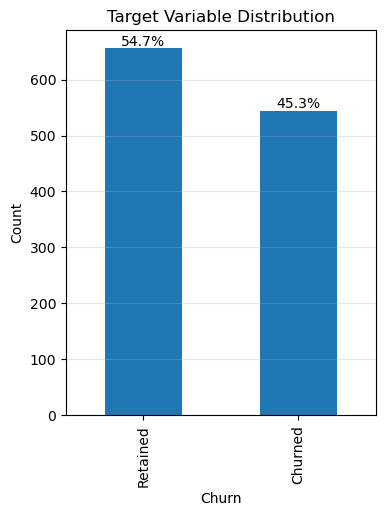

In [12]:
# Target distribution
target_counts = df[TARGET_COL].value_counts().sort_index()
target_percentages = (
    df[TARGET_COL]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

fig, ax = plt.subplots(figsize=(4, 5))

target_counts.plot(
    kind="bar",
    ax=ax
)

# Add percentage labels
for i, pct in enumerate(target_percentages):
    ax.text(
        i,
        target_counts.iloc[i],
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("Target Variable Distribution")
ax.set_xticklabels(["Retained", "Churned"])
ax.set_ylabel("Count")

ax.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- The target variable is reasonably balanced, with both classes well represented.
- Approximately 54.7% of customers were retained, while 45.3% churned.
- No severe class imbalance is observed at this stage.
- The presence of a substantial number of churned customers should enable meaningful analysis of churn-related patterns.
- Both classes contain enough observations to support downstream feature engineering and model development.

## Duplicate Record Analysis

In [13]:
duplicate_count = df.duplicated().sum()
duplicate_pct = df.duplicated().mean() * 100

print(f"Number of rows: {len(df):,}")
print(f"Number of duplicates: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

Number of rows: 1,200
Number of duplicates: 0
Duplicate percentage: 0.00%


### Observations

- No duplicate records were identified in the dataset.
- Each row appears to represent a unique customer record.
- Duplicate-related data quality issues are not a concern for this dataset.
- Duplicate validation remains an important step in the initial data quality assessment process.

## Missing Value Analysis

In [14]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean()* 100
        ).round(2)
})

missing_summary = (
    missing_summary
    .loc[missing_summary["Missing_Count"] > 0]
    .sort_values(
        by="Missing_Count",
        ascending=False
    )
)

missing_summary

,Missing_Count,Missing_Percentage
TotalCharges,114,9.50
InternetService,97,8.08
PaymentMethod,80,6.67


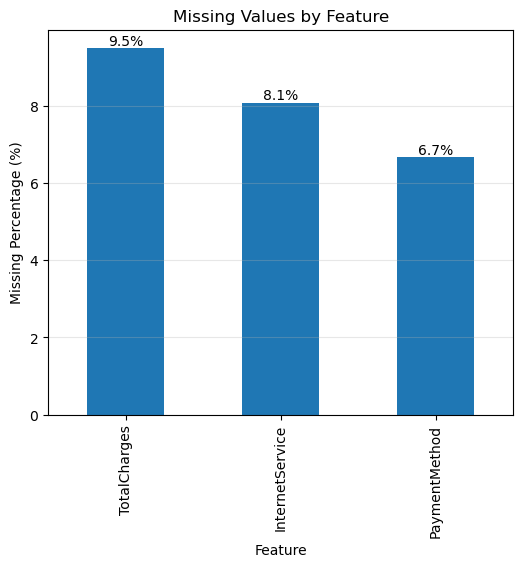

In [15]:
# Mssing Value distribution
missing_percentages = missing_summary["Missing_Percentage"]

fig, ax = plt.subplots(figsize=(6, 5))

missing_percentages.plot(
    kind="bar",
    ax=ax
)

# Add percentage labels
for i, pct in enumerate(missing_percentages):
      ax.text(
        i,
        pct,
        f"{pct:.1f}%",
        ha="center",
        va="bottom"
    )

ax.set_title("Missing Values by Feature")
ax.set_xlabel("Feature")
ax.set_ylabel("Missing Percentage (%)")

ax.grid(axis="y", alpha=0.3)

plt.show()

### Observations

- Missing values are present in three features: `TotalCharges`, `InternetService`, and `PaymentMethod`.
- `TotalCharges` contains the highest proportion of missing values (9.5%).
- Both numerical and categorical features contain missing values.
- Missing value treatment will be required before model training.
- The causes of missingness should be investigated before selecting an imputation strategy.

## Numerical Feature Exploration

Numerical feature distributions can reveal:

- skewness
- unusual values
- potential outliers
- transformation opportunities

The goal is to identify potential data quality issues and feature engineering opportunities before preprocessing.

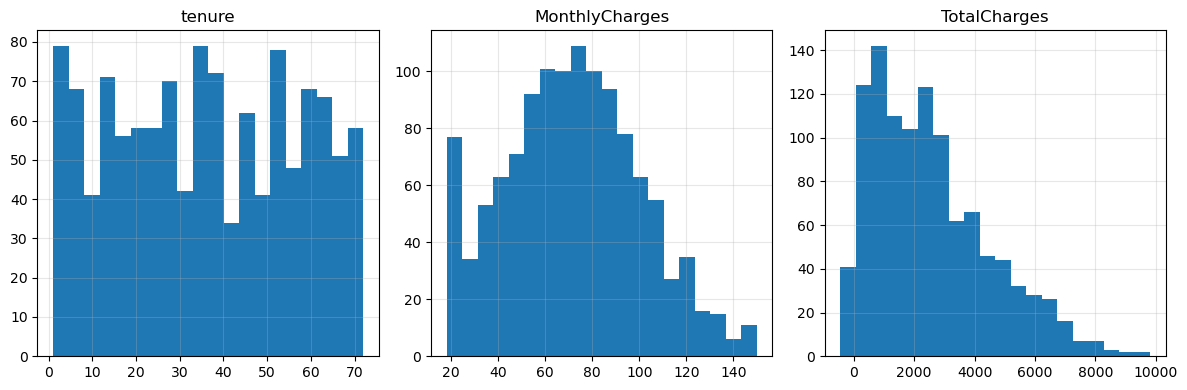

In [16]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(numerical_features),
    figsize=(12, 4)
)

for ax, feature in zip(axes, numerical_features):

    ax.hist(
        df[feature].dropna(),
        bins=20
    )

    ax.set_title(feature)
    ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

### Distribution Review

#### tenure

- Customers span both short and long tenures.
- The distribution covers multiple customer lifecycle stages.
- Tenure is likely to be an important churn-related feature.

#### MonthlyCharges

- Monthly charges span a wide range of values.
- The distribution appears moderately concentrated around the middle charge ranges.
- Multiple service plans or pricing tiers may be contributing to the observed distribution.

#### TotalCharges

- The distribution is strongly right-skewed.
- Most customers have relatively low-to-moderate total charges, while a smaller number have very large values.
- The long right tail suggests that transformations may be worth evaluating during feature engineering.
- The presence of negative values is unexpected and requires further investigation.

### Observations

- Numerical feature distributions vary substantially across the dataset.
- `tenure` spans both newer and long-term customers, indicating representation across different stages of the customer lifecycle.
- `MonthlyCharges` exhibits a broad distribution, suggesting the presence of multiple pricing tiers or service plans.
- `TotalCharges` is strongly right-skewed, with a small number of customers accumulating substantially higher charges than the majority.
- The presence of unexpected negative values in `TotalCharges` requires further investigation.
- `TotalCharges` is likely related to both `tenure` and `MonthlyCharges`, suggesting opportunities for derived, interaction, or ratio-based features in later stages of the notebook.

### Investigation: Negative Total Charges

The summary statistics and distribution plots revealed that `TotalCharges` contains negative values.

Because total customer charges are generally expected to be non-negative, these records require further investigation.

The objective is to determine:

- how many negative values exist
- whether they appear consistent with expected business behavior
- whether additional investigation is required

In [17]:
# Records with negative total charges
negative_total_charges = df.loc[
    df["TotalCharges"] < 0
]

negative_pct = (
    len(negative_total_charges)
    / len(df)
    * 100
)

print(
    f"Negative TotalCharges Records: {len(negative_total_charges)}\n"
    f"Negative TotalCharges Percent: {negative_pct:.2f}%"
)

negative_total_charges.head()

Negative TotalCharges Records: 29
Negative TotalCharges Percent: 2.42%


,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,InternetService,Contract,PaymentMethod,Churn
12,Female,0,2,83.80,-319.18,DSL,One year,NaN,0
87,Female,0,5,51.89,-10.21,DSL,One year,Electronic check,0
140,Male,0,3,79.85,-166.03,Fiber optic,Month-to-month,Mailed check,1
240,Male,0,20,21.45,-14.42,Fiber optic,Two year,Mailed check,0
253,Female,0,8,24.62,-54.86,Fiber optic,Month-to-month,Credit card,1


### Observations

- Multiple records contain negative values for `TotalCharges`.
- Negative charges are not generally expected from a business perspective and may indicate:
    - refunds or billing adjustments
    - data entry issues
    - synthetic data generation artifacts
- The cause of the negative values cannot be determined from the current analysis alone and would require additional domain knowledge.
- These records should be considered during future preprocessing and feature engineering decisions.

## Categorical Feature Exploration

Understanding category distributions can help identify:

- dominant categories
- rare categories
- potential encoding requirements
- grouping opportunities
- feature engineering opportunities

The goal is to understand category distributions and identify potential encoding, grouping, and feature engineering opportunities.

In [18]:
for feature in categorical_features:
    
    print('=' * 50)

    display(
    pd.DataFrame({
        "Count": df[feature].value_counts(dropna=False),
        "Percentage": (
            df[feature]
            .value_counts(normalize=True, dropna=False)
            * 100
        ).round(2)
    })
)

,Count,Percentage
gender,,
Female,604,50.33
Male,596,49.67


,Count,Percentage
InternetService,,
Fiber optic,493,41.08
DSL,457,38.08
No,153,12.75
NaN,97,8.08


,Count,Percentage
Contract,,
Month-to-month,626,52.17
One year,326,27.17
Two year,248,20.67


,Count,Percentage
PaymentMethod,,
Mailed check,288,24.00
Bank transfer,278,23.17
Electronic check,277,23.08
Credit card,277,23.08
NaN,80,6.67


,Count,Percentage
SeniorCitizen,,
0,1013,84.42
1,187,15.58


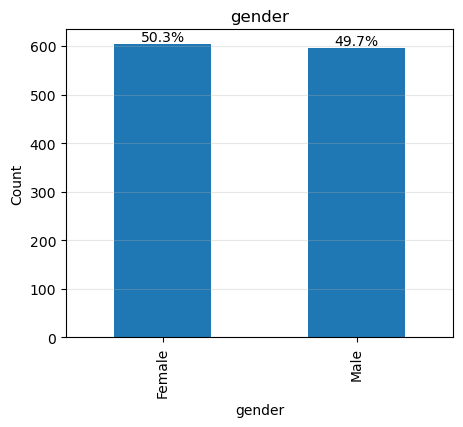

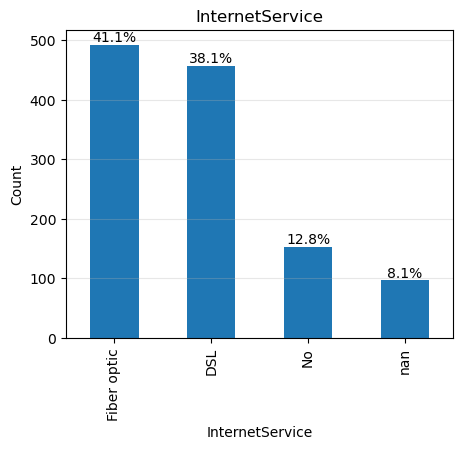

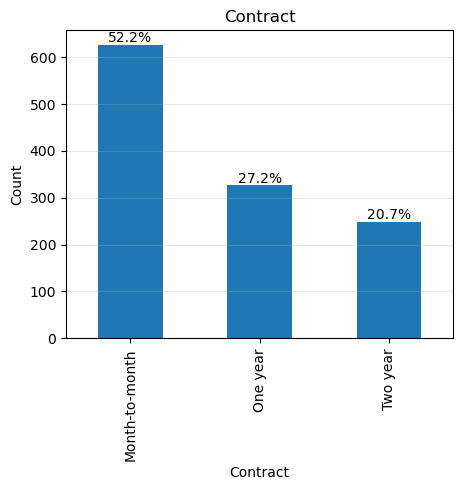

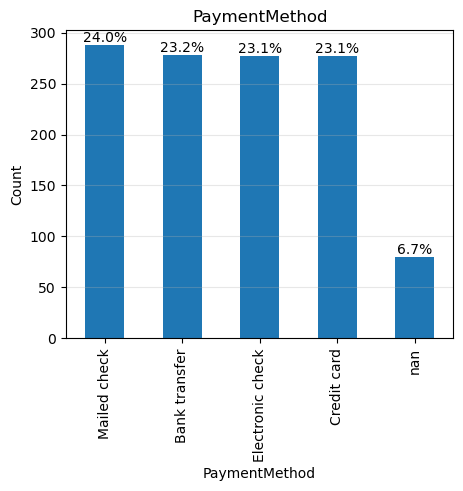

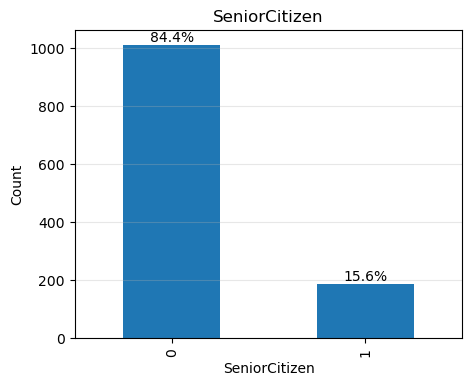

In [19]:
for feature in categorical_features:

    counts = (
        df[feature]
        .value_counts(dropna=False)
    )

    percentages = (
        df[feature]
        .value_counts(normalize=True, dropna=False)
        * 100
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    counts.plot(
        kind="bar",
        ax=ax
    )

    # Add percentage labels
    for i, pct in enumerate(percentages):
        ax.text(
            i,
            counts.iloc[i],
            f"{pct:.1f}%",
            ha="center",
            va="bottom"
        )

    ax.set_title(feature)
    ax.set_ylabel("Count")

    ax.grid(axis="y", alpha=0.3)

    plt.show()

### Feature Review

#### gender

- The distribution appears reasonably balanced across customer records.
- No obvious data quality concerns are observed.

#### SeniorCitizen

- Senior citizens represent a smaller customer segment.
- The feature may capture differences in service usage or retention behavior.

#### InternetService

- Multiple service offerings are represented.
- Service type may influence customer experience and retention.

#### Contract

- Multiple contract structures are present.
- Contract duration may influence customer commitment and service continuity.

#### PaymentMethod

- Multiple payment methods are represented.
- Payment behavior may reflect different customer preferences and engagement patterns.

### Observations

- Several categorical features represent meaningful business processes rather than simple customer attributes.
- Most categorical features exhibit low cardinality and should be straightforward to encode.
- Contract type, payment method, and internet service appear particularly relevant from a business and customer-behavior perspective.
- Missing values are present in certain categorical features and may require dedicated treatment during preprocessing.
- Certain features may present opportunities for grouping or business-driven feature engineering.
- No severe category sparsity issues are observed at this stage.

## Initial Feature Engineering Opportunities

### Purpose

The exploratory analysis identified several potential opportunities to improve the quality and usefulness of the feature set.

The objective of this section is to translate those findings into candidate feature engineering strategies that can be evaluated in later stages of the notebook.

These opportunities are currently hypotheses and will require implementation and validation before determining their impact on model performance.

---

### Missing Value Opportunities

Several features contain missing values, including:

- `TotalCharges`
- `InternetService`
- `PaymentMethod`

Potential approaches include:

- numerical imputation for missing continuous values
- categorical imputation for missing categories
- missing value indicators to capture potential missingness patterns

---

### Numerical Feature Opportunities

#### tenure

Potential opportunities:

- customer lifecycle segmentation
- tenure-based binning
- new vs established customer indicators

#### TotalCharges

Potential opportunities:

- skewness-aware transformations
- handling of unexpected negative values
- derived billing-related features

#### MonthlyCharges

Potential opportunities:

- spending-based customer segmentation
- interaction with customer tenure
- customer value representations

---

### Categorical Feature Opportunities

#### Contract

Potential opportunities:

- categorical encoding
- contract risk segmentation
- business-driven grouping strategies

#### PaymentMethod

Potential opportunities:

- categorical encoding
- missing value treatment
- payment behavior indicators

#### InternetService

Potential opportunities:

- categorical encoding
- service-level grouping strategies
- interaction with billing-related features

#### SeniorCitizen

Potential opportunities:

- interaction with service and billing features

---

### Derived Feature Opportunities

The exploratory analysis suggests that certain features may contain meaningful relationships.

Potential candidates include:

- billing-related interaction features
- tenure-adjusted spending features
- customer value indicators
- ratio-based features derived from account and billing information

In particular, `TotalCharges` appears likely to be related to both `tenure` and `MonthlyCharges`, suggesting opportunities for business-driven feature creation.

---

### Leakage Considerations

Feature engineering should be performed using information available at prediction time.

Potential future risks include:

- creating features that indirectly use target information
- using information unavailable during inference
- introducing train-test contamination during preprocessing

Leakage prevention will be explicitly evaluated in later sections of the notebook.

---

### Observations

- Multiple opportunities for feature engineering were identified during exploratory analysis.
- Missing value treatment is likely to play an important role in the preprocessing workflow.
- Several categorical features appear well suited for encoding and business-driven transformations.
- Numerical features present opportunities for transformation, segmentation, and derived feature creation.
- Relationships between billing and tenure-related features may provide useful predictive signals.
- All feature engineering ideas should ultimately be validated using downstream model performance.


## Key Findings and Next Steps

### Key Findings

- The dataset contains a mix of numerical and categorical features spanning customer demographics, account information, billing, and service-related attributes.
- Missing values are present in both numerical and categorical features and will require appropriate treatment during preprocessing.
- No duplicate records were identified in the dataset.
- `TotalCharges` contains unexpected negative values that require further investigation and preprocessing decisions.
- Numerical feature exploration revealed opportunities for transformation, segmentation, and derived feature creation.
- Several categorical features, particularly `Contract`, `PaymentMethod`, and `InternetService`, appear likely to contain meaningful business signals.
- Relationships between billing-related features and customer tenure suggest opportunities for interaction, ratio-based, and business-driven feature engineering.
- Multiple feature engineering opportunities were identified, but their usefulness must be validated through downstream model performance.

---

### Next Steps

The next stage of the notebook will focus on establishing a baseline modeling pipeline, including:

- train-test splitting
- missing value treatment
- categorical encoding
- feature scaling where appropriate
- baseline logistic regression modeling

The baseline model will provide a reference point for evaluating the impact of future feature engineering decisions.
